In [12]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

In [13]:
# Define Kalman Filter class
class KalmanFilter:
    def __init__(self, dt, process_var, measurement_var):
        self.dt = dt
        self.x = np.array([[0], [0]])  # Initial state: position and velocity
        self.F = np.array([[1, self.dt], [0, 1]])  # State transition matrix
        self.H = np.array([[1, 0]])  # Measurement matrix (we measure position only)
        self.Q = np.array([[process_var, 0], [0, process_var]])  # Process covariance
        self.R = np.array([[measurement_var]])  # Measurement covariance
        self.P = np.eye(2)  # Initial uncertainty

    def predict(self):
        self.x = np.dot(self.F, self.x)
        self.P = np.dot(self.F, np.dot(self.P, self.F.T)) + self.Q
        return self.x[0, 0]  # Return predicted position

    def update(self, z):
        S = np.dot(self.H, np.dot(self.P, self.H.T)) + self.R
        K = np.dot(self.P, np.dot(self.H.T, np.linalg.inv(S)))  # Kalman Gain
        y = z - np.dot(self.H, self.x)  # Measurement residual
        self.x = self.x + np.dot(K, y)  # Update state estimate
        self.P = (np.eye(self.H.shape[1]) - np.dot(K, self.H)) @ self.P  # Update uncertainty

In [16]:
def simulate_and_plot(data, lstm_model, sensor_features, loss_interval):
    # Initialize Kalman filter
    kf = KalmanFilter(dt=1.0, process_var=0.1, measurement_var=1.0)

    # Lists to store real and predicted positions
    real_positions = []
    predicted_positions = []

    gps_available = True
    current_real_position = data.iloc[0][['Lat', 'Lng']].values  # Start from the absolute GPS position
    current_pred_position = current_real_position  # Start predictions from the same point

    for t in range(len(data)):
        # Simulate GPS loss
        if t % loss_interval == 0:
            gps_available = not gps_available

        if gps_available:
            # Use actual GPS data (Lat, Lng)
            gps_position = data.iloc[t][['Lat', 'Lng']].values
            real_positions.append(gps_position)
            kf.update(gps_position)  # Update Kalman filter with real GPS data
            current_pred_position = gps_position  # Reset prediction to actual GPS during availability
        else:
            # Use LSTM to predict deltaLat, deltaLng
            X_input = data.iloc[t][sensor_features].values.reshape(1, 1, -1)
            lstm_prediction = lstm_model.predict(X_input) / 1000
            predicted_delta = lstm_prediction[0]  # deltaLat, deltaLng

            # Add delta to the previous predicted position
            current_pred_position += predicted_delta
            kf.update(current_pred_position)

        # Store the predicted position
        predicted_positions.append(current_pred_position)

    # Convert lists to arrays for plotting
    real_positions = np.array(real_positions)
    predicted_positions = np.array(predicted_positions)

    # Plot real vs predicted positions
    plt.figure(figsize=(10, 6))
    plt.plot(real_positions[:, 1], real_positions[:, 0], label='Real Path (GPS)', color='blue')
    plt.plot(predicted_positions[:, 1], predicted_positions[:, 0], label='Predicted Path (LSTM)', color='red', linestyle='--')
    plt.title('Real vs Predicted GPS Path')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
# Load the pre-trained LSTM model
lstm_model = load_model('lstm_delta_gps_model.keras')

In [7]:
# Load sensor data from the CSV
sensor_data = pd.read_csv('data/test/1_clean.csv', delimiter=';')

In [10]:
# Define the features used for LSTM input
input_features = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Tilt_X', 'Tilt_Y', 'Tilt_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Head', 'Temp', 'Press', 'delta_Alt']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

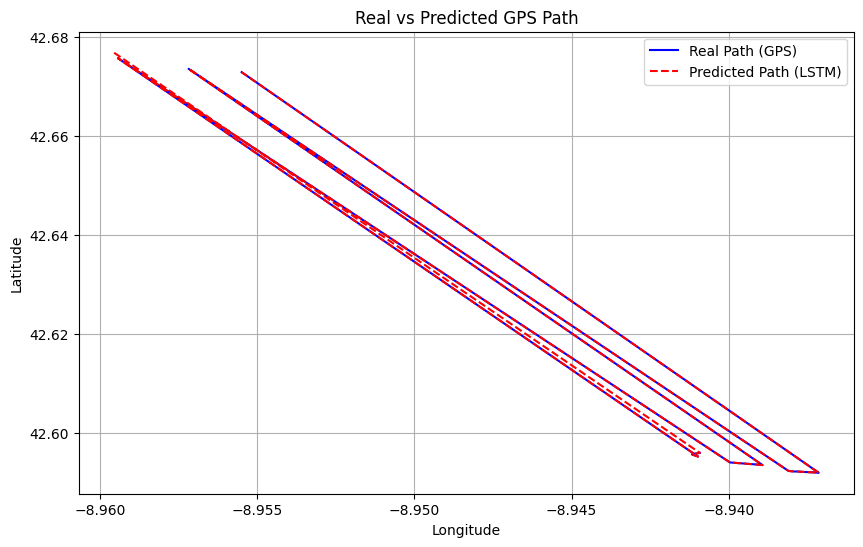

,Estimated_Position


In [17]:

# Run the simulation with GPS loss every 10 steps
predicted_positions = simulate_and_plot(sensor_data, lstm_model, input_features, loss_interval=10)

# Convert predictions to a DataFrame and show the results
predicted_positions_df = pd.DataFrame(predicted_positions, columns=['Estimated_Position'])
predicted_positions_df.head(10)